# Lab 09: Attention for Text Classification

In this lab you will build the core tools needed for PS7:

1. **From text to tensors** — tokenizing, vocabulary, encoding, and padding.
2. **Self-attention** — letting every token attend to every other token.

We use a small sample of IMDB movie reviews as a running example. The goal is to understand the mechanics — PS7 will ask you to apply these ideas to a different dataset.

In [38]:
import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

SEED = 251
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

---
## Part 1. From Text to Tensors

Neural networks work with numbers, not words. Before feeding text to a model we need three steps:

1. **Tokenize** — split the text into individual words.
2. **Build a vocabulary** — assign each word a unique integer ID.
3. **Encode and pad** — convert each text to a fixed-length list of integer IDs.

### 1.1 Load the data

We load 500 IMDB reviews — enough to build a vocabulary and fast to run.  
Each review is labeled **0** (negative) or **1** (positive).

In [39]:
from datasets import load_dataset  # pip install datasets

raw    = load_dataset('imdb')
sample = raw['train'].select(range(500))
texts  = sample['text']
labels = sample['label']   # 0 = negative, 1 = positive

label_str = 'positive' if labels[0] == 1 else 'negative'
print(f'Loaded {len(texts)} reviews')
print(f'\nExample review ({label_str}):')
print(texts[0][:300], '...')

Loaded 500 reviews

Example review (negative):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...


### 1.2 Tokenization

**Tokenization** splits a raw string into a list of words.  
We lowercase everything, remove punctuation, and split on whitespace.

In [40]:
def tokenize(text):
    text = text.lower()
    text = re.sub('[^a-z0-9]+', ' ', text)
    return text.strip().split()

print(tokenize('I loved this movie. It was absolutely brilliant!'))
print(tokenize('Zimmerian soundtrack! Not much more than that :( '))

['i', 'loved', 'this', 'movie', 'it', 'was', 'absolutely', 'brilliant']
['zimmerian', 'soundtrack', 'not', 'much', 'more', 'than', 'that']


### 1.3 Building a vocabulary

A **vocabulary** is a dictionary: `word -> integer ID`.

We always reserve two special slots:
- **ID 0** → `<pad>` — a dummy token used to fill short sequences to a fixed length.
- **ID 1** → `<unk>` — stands for any word not in the vocabulary.

We count word frequencies across all training texts and keep only the most common words.

In [41]:
counter = Counter()
for text in texts:
    counter.update(tokenize(text))

print(f'Unique words in sample: {len(counter)}')
print(f'\nTop 10 most common:')
for word, count in counter.most_common(10):
    print(f'  {word!r}: {count}')

Unique words in sample: 10862

Top 10 most common:
  'the': 6261
  'a': 3069
  'and': 2946
  'of': 2694
  'to': 2640
  'br': 2132
  'is': 1984
  'it': 1890
  'in': 1845
  'i': 1739


In [42]:
MAX_VOCAB = 3000

vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[word] = len(vocab)

PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

print(f'Vocabulary size: {len(vocab)}')
print(f'\nWord -> ID examples:')

for word in ['the', 'movie', 'great', 'terrible', 'love', 'zxqwerty']:
    idx  = vocab.get(word, UNK_IDX)
    note = '  <- unknown word' if idx == UNK_IDX else ''
    print(f'  {word!r} -> {idx}{note}')

Vocabulary size: 3000

Word -> ID examples:
  'the' -> 2
  'movie' -> 16
  'great' -> 137
  'terrible' -> 218
  'love' -> 120
  'zxqwerty' -> 1  <- unknown word


### 1.4 Encoding and padding

To batch texts together, they all need the **same length** (`MAX_LEN`).

The `encode` function:
1. tokenizes the text,
2. maps each token to its vocabulary ID (`<unk>` for missing words),
3. **truncates** if the sequence is longer than `MAX_LEN`,
4. **pads** with `PAD_IDX` (0) at the end if it is shorter.

In [43]:
MAX_LEN = 20  # short for readability; PS7 uses 25

def encode(text, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids    = [vocab.get(tok, UNK_IDX) for tok in tokens]
    ids    = ids[:max_len]                            # truncate
    ids    = ids + [PAD_IDX] * (max_len - len(ids))  # pad
    return ids

short = 'I loved this film'
long  = 'This was absolutely the most incredible film I have ever seen in my entire life and I cannot recommend it enough'

print(f'Short ({len(tokenize(short))} tokens):')
print(f'  tokens : {tokenize(short)}')
print(f'  encoded: {encode(short)}')
print()
print(f'Long ({len(tokenize(long))} tokens, truncated to {MAX_LEN}):')
print(f'  encoded: {encode(long)}')
print(f'\nBoth have exactly {MAX_LEN} elements.')

Short (4 tokens):
  tokens : ['i', 'loved', 'this', 'film']
  encoded: [11, 1557, 12, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Long (21 tokens, truncated to 20):
  encoded: [12, 15, 372, 2, 110, 1163, 20, 11, 26, 103, 113, 10, 72, 382, 123, 4, 11, 369, 363, 9]

Both have exactly 20 elements.


The short review ends with **0s** (padding). The long review is **cut off** at 20 tokens.

When building a model, padding tokens should not influence predictions — you need to mask them out!

In [53]:
# Pick one review and prepare the embedding matrix
idx           = 3
example_text  = texts[idx]
example_label = labels[idx]
print(f'Label: {"positive" if example_label == 1 else "negative"}')
print(f'Text : {example_text[:200]}...\n')

ids  = encode(example_text)     # list of MAX_LEN ints
x    = torch.tensor(ids)        # (MAX_LEN,)

embed_dim       = 8
id_to_word      = {v: k for k, v in vocab.items()}
torch.manual_seed(SEED)
embedding_layer = nn.Embedding(len(vocab), embed_dim, padding_idx=PAD_IDX)
X               = embedding_layer(x)   # (MAX_LEN, embed_dim)

token_labels = [id_to_word.get(int(i), '<unk>') for i in ids]

print(f'Tokens : {token_labels}')
print(f'X shape: {X.shape}  ({MAX_LEN} positions x {embed_dim} dims)')

Label: negative
Text : This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impre...

Tokens : ['this', 'film', 'was', 'probably', 'inspired', 'by', '<unk>', 's', '<unk>', 'f', '<unk>', 'and', 'i', 'urge', 'you', 'to', 'see', 'that', 'film', 'instead']
X shape: torch.Size([20, 8])  (20 positions x 8 dims)


---
## Part 2. Self-Attention

We continue with the same IMDB review encoded and embedded in the setup cell above.

**Self-attention** produces a new representation for **every token**, where each token's new vector is a weighted mix of information from all other tokens in the sequence.

### Queries, Keys, and Values

Self-attention uses three learned linear projections of `X`:

```
Q = X @ W_q    (Queries — what is this token looking for?)
K = X @ W_k    (Keys    — what information does this token offer?)
V = X @ W_v    (Values  — what does this token actually contribute?)
```

Token `i` attends to token `j` based on how well query `q_i` matches key `k_j`.

One extra detail: padding tokens should not be attended to. Before applying softmax,
**columns** corresponding to padding positions are masked to -∞.

In [45]:
# X shape: (MAX_LEN, embed_dim) = (20, 8)  — from the setup cell above
d_attn = embed_dim   # keep the same dimension for simplicity
scale  = math.sqrt(d_attn)

torch.manual_seed(42)
W_q = torch.randn(embed_dim, d_attn)
W_k = torch.randn(embed_dim, d_attn)
W_v = torch.randn(embed_dim, d_attn)

Q = X.detach() @ W_q   # (MAX_LEN, d_attn)
K = X.detach() @ W_k
V = X.detach() @ W_v

print(f'Input X : {X.shape}   (token positions x embed_dim)')
print(f'Q shape : {Q.shape}   (one query vector per token)')
print(f'K shape : {K.shape}   (one key   vector per token)')
print(f'V shape : {V.shape}   (one value vector per token)')

Input X : torch.Size([20, 8])   (token positions x embed_dim)
Q shape : torch.Size([20, 8])   (one query vector per token)
K shape : torch.Size([20, 8])   (one key   vector per token)
V shape : torch.Size([20, 8])   (one value vector per token)


### Step 1 — Pairwise scores

For every pair `(i, j)`, compute how much token `i` should attend to token `j`:

```
S[i, j] = dot(q_i, k_j) / sqrt(d_attn)
```

In matrix form: `S = Q @ K.T / sqrt(d_attn)`

The result is a `(MAX_LEN x MAX_LEN)` score matrix — one score per token pair.

In [46]:
scores_sa = Q @ K.T / scale   # (MAX_LEN, MAX_LEN)

print(f'Score matrix shape: {scores_sa.shape}  (one score per token pair)')
print('scores_sa[i, j] = how much token i wants to attend to token j')
print(f'\nTop-left 5x5 corner (first 5 tokens x first 5 tokens):')
print(scores_sa[:5, :5].round(decimals=2))

Score matrix shape: torch.Size([20, 20])  (one score per token pair)
scores_sa[i, j] = how much token i wants to attend to token j

Top-left 5x5 corner (first 5 tokens x first 5 tokens):
tensor([[ 7.2200,  1.0700, 13.8800, -2.4000, -5.8500],
        [ 3.2400,  4.2700,  5.1600, -0.0800,  6.7700],
        [-6.0200, 21.7900, 28.4500, -4.3100,  5.6700],
        [ 4.0100, -7.8500, -4.0400,  4.1100, -3.9600],
        [ 5.2300,  1.1800,  3.7000, -2.5800,  2.8000]])


### Step 2 — Row-wise softmax (with padding mask)

Apply softmax **along each row** so each token's attention weights sum to 1.
Row `i` tells you how token `i` distributes its attention across all positions.

Before softmax, we mask **columns** that correspond to padding positions to -∞.
This forces every token to give zero weight to padding keys — padding never contributes information.

Attention matrix shape: torch.Size([20, 20])
Row sums (should all be 1.0): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


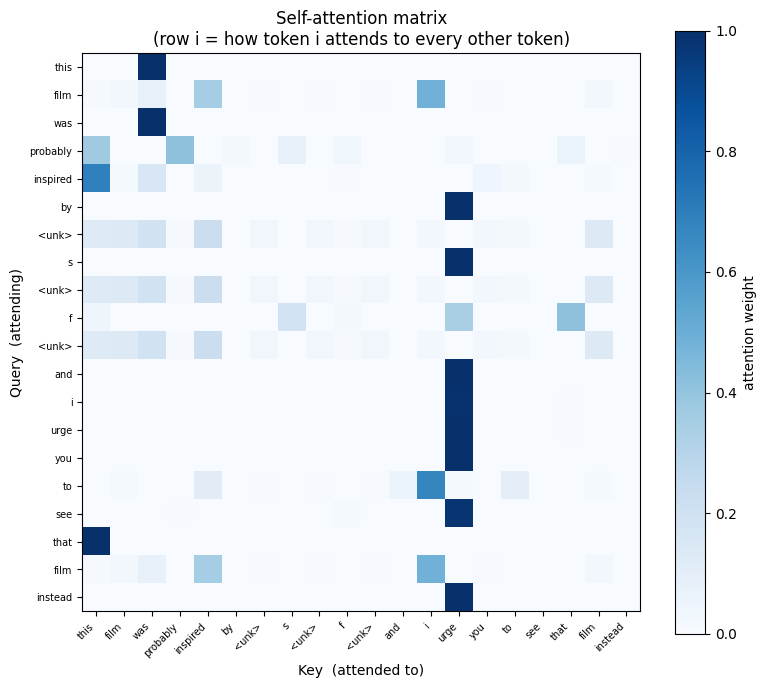

In [47]:
# Mask padding key positions (columns): (MAX_LEN,) -> (1, MAX_LEN) broadcasts across all rows
key_mask  = (x == PAD_IDX).unsqueeze(0)                          # (1, MAX_LEN)
scores_sa = scores_sa.masked_fill(key_mask, float('-inf'))

attn_sa   = torch.softmax(scores_sa, dim=1)                      # (MAX_LEN, MAX_LEN)

print(f'Attention matrix shape: {attn_sa.shape}')
print(f'Row sums (should all be 1.0): {attn_sa.sum(dim=1).round(decimals=3).tolist()}')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(attn_sa.detach(), cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(MAX_LEN))
ax.set_yticks(range(MAX_LEN))
ax.set_xticklabels(token_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(token_labels, fontsize=7)
ax.set_xlabel('Key  (attended to)')
ax.set_ylabel('Query  (attending)')
plt.colorbar(im, ax=ax, label='attention weight')
plt.title('Self-attention matrix\n(row i = how token i attends to every other token)')
plt.tight_layout()
plt.show()

### Step 3 — Output

Each token's new representation is a weighted mixture of the **value** vectors:

```
output[i] = sum_j( attn[i, j] * v_j )
```

In matrix form: `output = attn @ V`

The output has the **same shape as the input** — one vector per token — but each vector now carries context from the whole sequence.

In [48]:
context = attn_sa @ V   # (MAX_LEN, d_attn)

print(f'Context shape: {context.shape}  (same number of tokens, new representations)')
print()

first_word = id_to_word.get(ids[0], '<unk>')
print(f'Token "{first_word}" before self-attention: {X.detach()[0].round(decimals=2).tolist()}')
print(f'Token "{first_word}"  after self-attention: {context[0].round(decimals=2).tolist()}')
print()
print(f'The new vector for "{first_word}" mixes information from all other tokens,')
print('weighted by how much it attended to each of them.')

Context shape: torch.Size([20, 8])  (same number of tokens, new representations)

Token "this" before self-attention: [-1.8899999856948853, -0.699999988079071, 1.409999966621399, 1.4900000095367432, -0.5400000214576721, 0.4300000071525574, 0.47999998927116394, -0.5199999809265137]
Token "this"  after self-attention: [3.3399999141693115, 7.510000228881836, 3.319999933242798, 0.5699999928474426, -4.860000133514404, 5.519999980926514, 0.6800000071525574, 7.260000228881836]

The new vector for "this" mixes information from all other tokens,
weighted by how much it attended to each of them.


### 2.4 Putting it together: a self-attention classifier

To classify a sentence with self-attention you need one extra step compared to a simpler pooling model,
because self-attention preserves the sequence length — you still need to collapse to one vector before classifying.

| Step | Operation | Shape in → Shape out |
|---|---|---|
| Embed | `nn.Embedding` | (batch, seq_len) → (batch, seq_len, embed_dim) |
| Project | `W_q`, `W_k`, `W_v` | (batch, seq_len, embed_dim) → (batch, seq_len, d_attn) each |
| Self-attention | `Q @ K.T / scale` → mask → softmax → `@ V` | (batch, seq_len, d_attn) → (batch, seq_len, d_attn) |
| Pool | mean over real tokens | (batch, seq_len, d_attn) → (batch, d_attn) |
| Classify | `nn.Linear` | (batch, d_attn) → (batch, num_classes) |

In [49]:
class SelfAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, d_attn, num_classes=2, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.scale   = math.sqrt(d_attn)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.W_q = nn.Linear(embed_dim, d_attn, bias=False)
        self.W_k = nn.Linear(embed_dim, d_attn, bias=False)
        self.W_v = nn.Linear(embed_dim, d_attn, bias=False)
        self.fc  = nn.Linear(d_attn, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)                              # (batch, seq_len, embed_dim)
        Q   = self.W_q(emb)                                  # (batch, seq_len, d_attn)
        K   = self.W_k(emb)
        V   = self.W_v(emb)

        scores   = Q @ K.transpose(-2, -1) / self.scale     # (batch, seq_len, seq_len)
        key_mask = (x == self.pad_idx).unsqueeze(1)          # (batch, 1, seq_len)
        scores   = scores.masked_fill(key_mask, float('-inf'))
        attn     = torch.softmax(scores, dim=-1)             # (batch, seq_len, seq_len)

        context   = attn @ V                                 # (batch, seq_len, d_attn)

        # Mean pool over real tokens only
        real_mask = (x != self.pad_idx).unsqueeze(-1).float()          # (batch, seq_len, 1)
        pooled    = (context * real_mask).sum(dim=1) / real_mask.sum(dim=1).clamp(min=1.0)

        return self.fc(pooled)                               # (batch, num_classes)


model_sa = SelfAttentionClassifier(vocab_size=len(vocab), embed_dim=8, d_attn=8)
print(model_sa)
print(f'\nTotal parameters: {sum(p.numel() for p in model_sa.parameters()):,}')

SelfAttentionClassifier(
  (embedding): Embedding(3000, 8, padding_idx=0)
  (W_q): Linear(in_features=8, out_features=8, bias=False)
  (W_k): Linear(in_features=8, out_features=8, bias=False)
  (W_v): Linear(in_features=8, out_features=8, bias=False)
  (fc): Linear(in_features=8, out_features=2, bias=True)
)

Total parameters: 24,210


In [50]:
# Encode two reviews and run a forward pass
torch.manual_seed(SEED)
model_sa = SelfAttentionClassifier(vocab_size=len(vocab), embed_dim=8, d_attn=8)

batch = torch.tensor([encode(texts[0]), encode(texts[1])])   # (2, MAX_LEN)

with torch.no_grad():
    logits = model_sa(batch)

print(f'Batch shape : {batch.shape}  (2 reviews x {MAX_LEN} token positions)')
print(f'Logits shape: {logits.shape}  (2 reviews x 2 classes)\n')
print(f'Logits:\n{logits.round(decimals=3)}')
print(f'\nPredicted: {torch.argmax(logits, dim=1).tolist()}  (0 = negative, 1 = positive)')
print(f'True     : {[labels[0], labels[1]]}')
print()
print('Predictions are random — the model has not been trained yet.')
print('In PS7 you will train a version of this classifier on a real dataset.')

Batch shape : torch.Size([2, 20])  (2 reviews x 20 token positions)
Logits shape: torch.Size([2, 2])  (2 reviews x 2 classes)

Logits:
tensor([[ 0.2340, -0.0270],
        [ 0.3330, -0.2960]])

Predicted: [0, 0]  (0 = negative, 1 = positive)
True     : [0, 0]

Predictions are random — the model has not been trained yet.
In PS7 you will train a version of this classifier on a real dataset.
